<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Toxic_Text_Classification_Comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [3]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [5]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [6]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [7]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [8]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [9]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [10]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

In [11]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [12]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [13]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [14]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [15]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [16]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [17]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id                                       comment_text  toxic  \
0  00001cee341fdb12  Yo bitch Ja Rule is more succesful then you'll...    NaN   
1  0000247867823ef7  == From RfC == \n\n The title is fine as it is...    NaN   
2  00013b17ad220c46  " \n\n == Sources == \n\n * Zawe Ashton on Lap...    NaN   
3  00017563c3f7919a  :If you have a look back at the source, the in...    NaN   
4  00017695ad8997eb          I don't anonymously edit articles at all.    NaN   

   severe_toxic  obscene  threat  insult  identity_hate  
0           NaN      NaN     NaN     NaN            NaN  
1           NaN      NaN     NaN     NaN            NaN  
2           NaN      NaN     NaN     NaN            NaN  
3           NaN      NaN     NaN     NaN            NaN  
4           NaN      NaN     NaN     NaN            NaN  


**Binary 'any_toxic' column **




In [18]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [19]:
# print(f'Total comments : {len(df):,}')
# print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
# print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

# Exploratory Data Analysis (EDA)

In [20]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

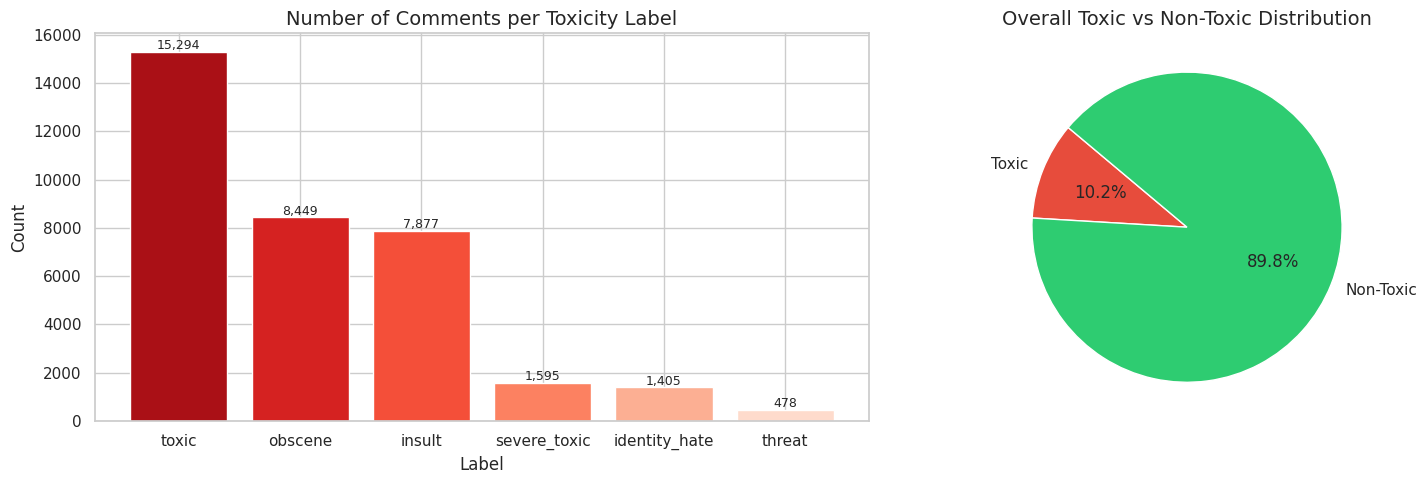

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [22]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

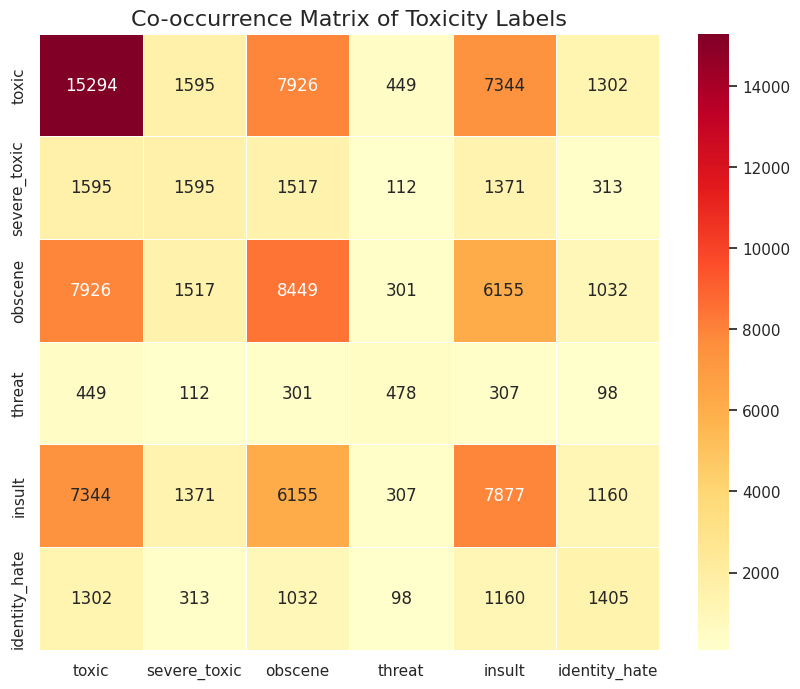

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

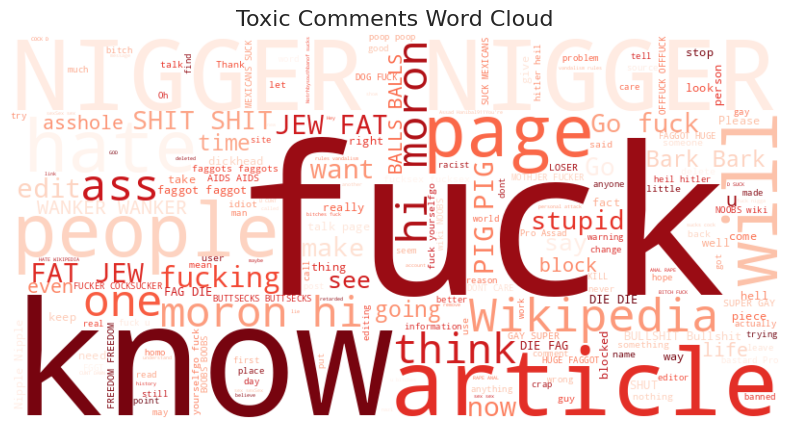

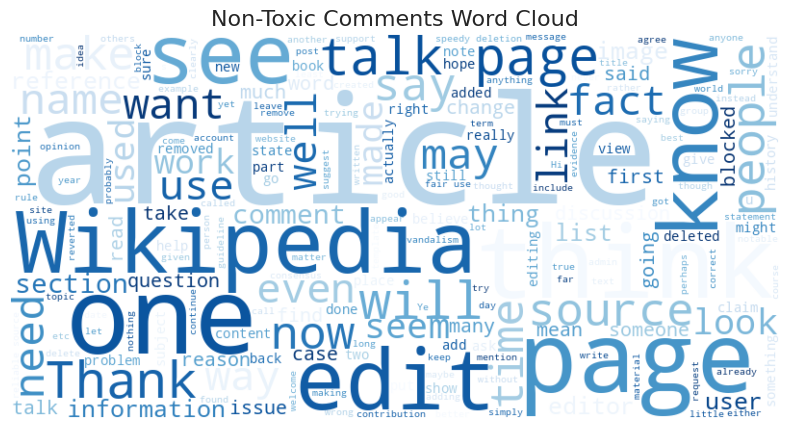

In [24]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

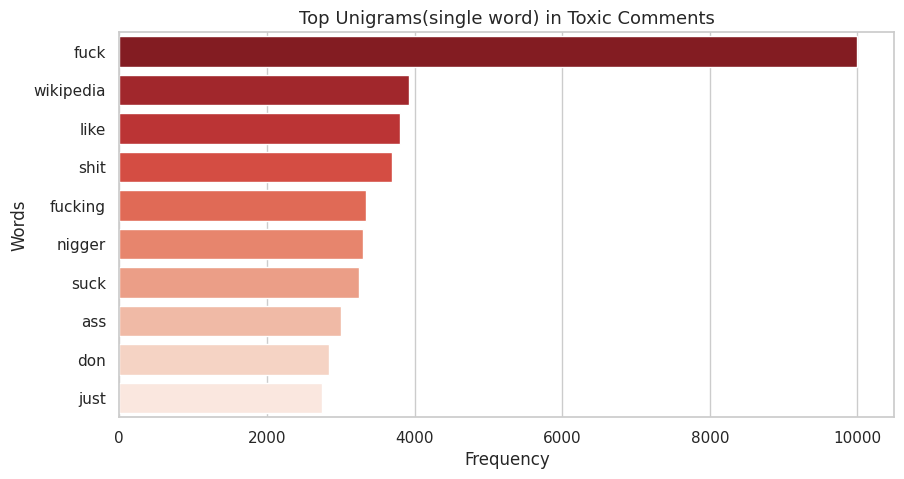

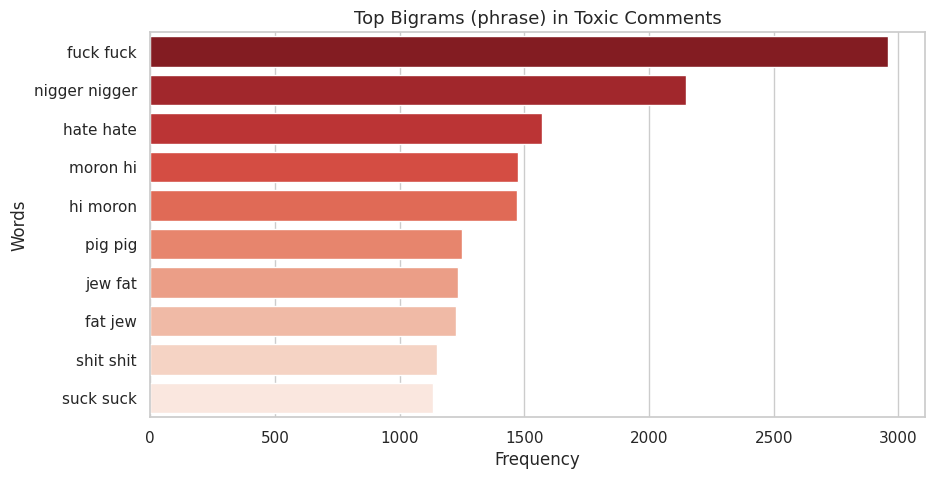

In [25]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [26]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
929,"""\nThat admission begs the question """"Is it be...",0
102200,""":Do you mean """"where can I find a list of Hob...",0
80118,In 1987 film Planes Trains and Automobiles a c...,0
36286,"""__NOINDEX__\n\n Wikipedia_talk:Hatnote \nThan...",0
144466,Fruity Pebbles Fan Club? \n\nWhy won't it let ...,0
46909,"""\nHmm! Thanks for the info. §§§§ {T/C} """,0


**Basic Preprocessing**



1.   Lower case




In [27]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [28]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [29]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [30]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [31]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [32]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [33]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.2 MB/s eta 0:00:00


1. Emoji to text

In [34]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [35]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [36]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [37]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [38]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [39]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [40]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [41]:
# print("Original text:", sample_text)
# print("Clean text:", clean_text)
# print("Tokens:", tokens)

NameError: name 'sample_text' is not defined

Stopwords

In [42]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [43]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [44]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [ ]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [45]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [46]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
27789,"Cptnono, are you exempt from your own insistence that users be addressed by their full usernames?"
139413,"Thanks! We now have South Pacific at FAC . We would very much value any comments by you there, as this is the most important musical that we have yet brought to FAC. All the best!"
13323,"Agreed. Doesn't Wikipedia have an article on /b/, or just 4chan? Either way, we should probably just throw up a link for anyone who's confused."
77451,I was annoying? You call trying to remove the toxicity from this article annoying? VsevolodKrolikov you define annoying.
64754,"Blocked? \n\nI seem to be blocked, and I am not quite sure the reason. I would appreciate an explanation from someone. (PowWow)"


Applying Basic Preprocessing

In [47]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

,basic_clean
10078,i reverted your bold edit i am not passing judgment on the actual edit but on the principle that it is inappropriate to change an mos to suit an active debate changes to the mos should generally be discussed but even more so when a debate on one page affects multiple pages going forward contact me
44664,hi guy what is your faverout band
98295,your facts are wrong i havent identified myself as gay or straight for that matter i favour inclusion of the reference because its an significant piece of information and while i dont doubt that maddins loss was disappointing to him such terminology doesnt meet the standard for inclusion on this forum
97230,theres nothing on the relevant discussion page and i encourage you to cite your sources
111183,believe me this was a serious lesson i now understand that i was wrong and promise that i will avoid any more issues if at all possible thank you so much again jaranda am i going to be unblocked now or am i gonna still have to wait until pm tomorrow talk


Comparison Of Raw and Basic Clean by Basic Preprocessing

In [48]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
113161,".\n\n````\nI find it odd that my user name is such a big deal when there are pictures of people masturbating and descriptions of sex acts and violent crimes in this encyclopedia. I don't want to seem standoffish, but I just see it as strange. I didn't mean to offend anyone, I just thought my username was kind of funny",i find it odd that my user name is such a big deal when there are pictures of people masturbating and descriptions of sex acts and violent crimes in this encyclopedia i dont want to seem standoffish but i just see it as strange i didnt mean to offend anyone i just thought my username was kind of funny
109176,"""\n\nReversion of """"vandalism""""\nYou on the sixth of October reverted the edit we made to the articleColumbus Alternative High School (as the user , admitadly almost every edit we have ever made has been untter and blatant vandalism, however this single edit wasn't, we changed """"Advanced Placement"""" to """"Advanced Placement Program"""", a minor edit yes, but a valid one.\n\nThis is a meaningless complaint we admit, and it would not be unwarranted to ban this account immediately, however we find it annoying that you reverted our edit to an edit that had the principles name reading """"Fucking Retard"""" (this has since been reverted).\n\nWe don't know why we're even bothering complaining, and feel free to ban us, we'll deserve it eventually, but for the sake of the little credibility this shit hole has, don't do blind reversions, you never know what might be reverted.\n\nWe have fixed your mistake, that will be all. """,reversion of vandalism you on the sixth of october reverted the edit we made to the articlecolumbus alternative high school as the user admitadly almost every edit we have ever made has been untter and blatant vandalism however this single edit wasnt we changed advanced placement to advanced placement program a minor edit yes but a valid one this is a meaningless complaint we admit and it would not be unwarranted to ban this account immediately however we find it annoying that you reverted our edit to an edit that had the principles name reading fucking retard this has since been reverted we dont know why were even bothering complaining and feel free to ban us well deserve it eventually but for the sake of the little credibility this shit hole has dont do blind reversions you never know what might be reverted we have fixed your mistake that will be all
119552,the spellings of the two occurrences of the word,the spellings of the two occurrences of the word
155395,"Euston Manifesto \n\nHello, Rwendland! In re: my change to your change: you're welcome. Once again it's nice to have another civilised and thoughtful interaction with a fellow Wikipedian.",euston manifesto hello rwendland in re my change to your change youre welcome once again its nice to have another civilised and thoughtful interaction with a fellow wikipedian
37584,Just for make sure ;),just for make sure


Applying Advanced Preprocessing

In [54]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [55]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
119105,geez forgetful weve already discussed marx anarchist ie wanted use state mold socialist man ergo statist opposite anarchist know guy say get old teeth fall hell quit eating meat would call vegetarian
131631,carioca rfa thanks support request adminship final outcome administrator comment concern action administrator please let know thank
125326,birthday worry enjoy ur daytalke
111256,pseudoscience category im assuming article pseudoscience category association creationism however modern scientificallyaccepted variant catastrophism nothing creationism theyre even mentioned article think connection pseudoscience need clarified article made general less creationismspecific category tag removed entirely
83590,phrase exists would provided search engine even mentioned page available whole


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [56]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
80988,"""\n\nI have struck out my comment on the WP:RfC page, as you are quite correct in saying that I have no evidence for my """"suspicion"""", although I don't agree with your comment that you had """"already explained that you have been browsing WP for some time"""" - I can't see where you explained this previously. (talk) """,struck comment wprfc page quite correct saying evidence suspicion although agree comment already explained browsing wp time see explained previously talk
141463,please do not reinsert,please reinsert
44537,"""\n\nwell its not """"Vanderlism"""" as you state it. You still should allow the other part of my edit that you keep reverting because you hate the genre so much. 75.139.103.133 """,well vanderlism state still allow part edit keep reverting hate genre much
10601,"""\nFor the record, here is the news blurb that made en.wiki main page news: """"Amid an outbreak of tornadoes and derechos in central and eastern North America, a tornado hits a Boy Scout camp in Iowa, killing four.""""... — • Talk • """,record news blurb made enwiki main page news amid outbreak tornado derechos central eastern north america tornado hit boy scout camp iowa killing four talk
149256,"cajuns, acadians\nCajuns, acadians, louisianans, they're so many different names for different americans of french descent because their culture is so rich and somewhat so different but so close at the same time. I'm an acadian but more importantly I'm a french american so I really don't see why there should be a difference. \n\nIf you say there should be two different list, it doesn't make sense. The people on the french-american list should be in one of wiki-invented list of cajuns or acadians. I understand there are some more recent french-americans who are only 1 or 2 generations-old americans but this distinction isn't made for italian-americans, german-americans. I'm surprised to see Albert Einstein a fairly recent immigrant in American history next to Katherine Heigl, a 10 to 12 generations american. \\\n\nThis is all race-based, biased because french-bashing don't stop at the bush government level.",cajun acadian cajun acadian louisianan theyre many different name different american french descent culture rich somewhat different close time im acadian importantly im french american really see difference say two different list doesnt make sense people frenchamerican list one wikiinvented list cajun acadian understand recent frenchamericans generationsold american distinction isnt made italianamericans germanamericans im surprised see albert einstein fairly recent immigrant american history next katherine heigl generation american racebased biased frenchbashing stop bush government level


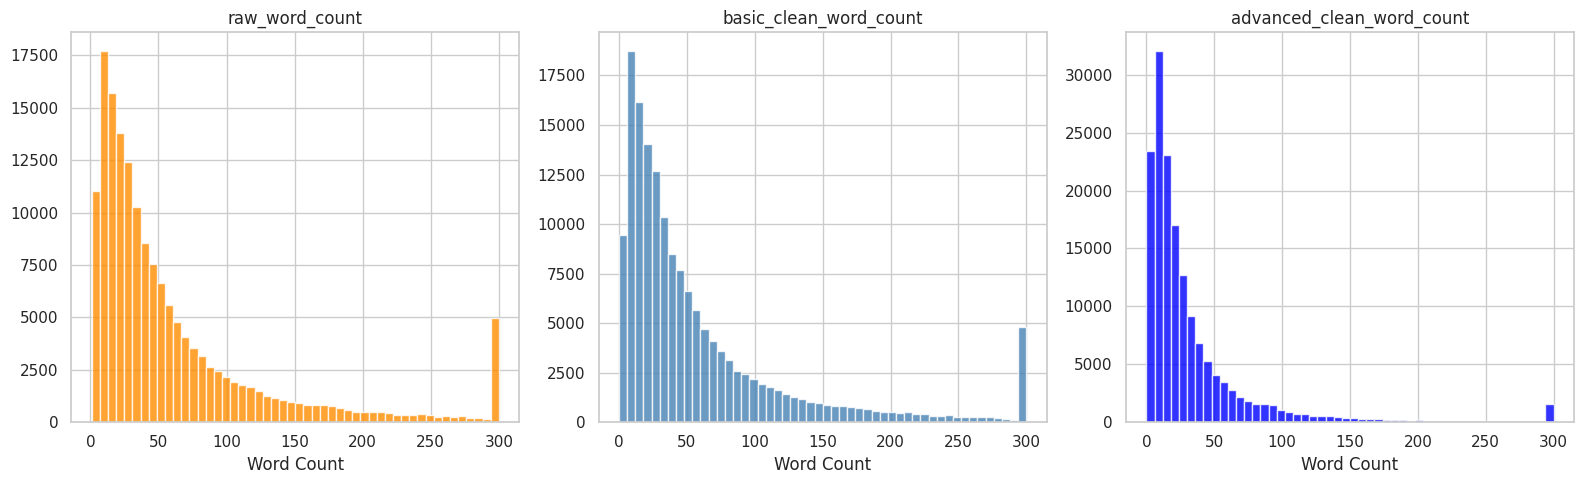

In [57]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [58]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [59]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [60]:
for i in range(5):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [62]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [64]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [65]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [66]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [67]:
Vocab_size =30000
max_len= 200

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts) # Corrected method name to texts_to_sequences
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [68]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 200)
LSTM shape val (15957, 200)
LSTM shape test (15958, 200)


3. BERT Tokenizer (for BERT) \
raw dataset

In [69]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [70]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Evaluation toolkit
for comparing easily

In [71]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)


In [72]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]


In [73]:
def plot_confusion(model_name,y_true, y_pred, labels, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), labels):
       cm = confusion_matrix(y_true[:, labels.index(col)],
                              y_pred[:, labels.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# Model 1 — TF-IDF + Logistic Regression



## 1. Raw text version



In [74]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0


Evaluate the model for raw data

In [ ]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)

Confusion plot for the model for raw data

In [ ]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

## 2. Advanced clean version

In [ ]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

In [ ]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)

In [ ]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

The raw-text TF-IDF representation outperformed the advanced preprocessed version across all evaluation metrics. Excessive preprocessing may remove important contextual and emotional cues that contribute to toxicity identification.